In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp


import rover as rover_class
import grid_world
from astar_plan import AStarPlanner

import mpc_EKF
import mpc
# from mpc import *
np.random.seed(4)

In [2]:
# set-up orbit epoch, number of satellites, number of planes, and number of satellites per plane
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")
N_sat = 6
N_planes = 2
N_sat_plane = N_sat // N_planes
# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 6142.4  # [km] Semi-major axis
ecc = [0.6, 0.6]  # [-] Eccentricity
inc = np.deg2rad([57.7, 57.7])  # [rad] Inclination
raan = np.deg2rad([0, 180])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([90, 90])  # [rad] Argument of periapsis
ma = np.deg2rad([120, 240, 0])  # [rad] Mean anomaly

# group the together and create the initial state vectors
coe_mi = np.zeros((N_sat, 6))
rv0_moon_sat_mi = np.zeros((N_sat, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i_sat = i_pl * N_sat_plane + i_spl
        coe_mi[i_sat] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )
        rv0_moon_sat_mi[i_sat] = pnt.classical_to_cartesian(coe_mi[i_sat], pnt.MU_MOON)

# Time discretization
# TODO: this is where we can change things up depending on the simulation scenario
sma = coe_mi[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 6 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 6 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
# NOTE: 3 days of simulation time takes 2 minutes and 36 seconds of computation time with the current time step
N_days = 1  # [-] Number of days
tf = N_days * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt) + 1  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body with Earth, no Sun included)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
# dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.CoordConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MI, pnt.PA
    )


Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


## Save the satellite positions as a csv file

In [3]:
# save the satellite positions as a csv file
# for i_sat in range(N_sat):
#     df = pd.DataFrame(rv_moon_sat_pa[i_sat])
#     #set the column names
#     df.columns = ["x", "y", "z", "vx", "vy", "vz"]
#     # add a time column at the beginning
#     df.insert(0, "time", tspan)
#     df.to_csv(f"data/sat_{i_sat}.csv", index=False, header=True)


In [4]:
def get_pseudorange_measurement(satpos, x_est, use_Gnoise):
    # simulate pseudorange measurements from a given satellite
    # likely inputs: true satellite state, true receiver state
    # we can already add noise to the measurements here, or outside like in the MATLAB simulator
    # the pseudorange error model is the same as what we had from the endurance work
    # also let's get the Jacobian here too (maybe JAX can come in handy!)
    
    # x_est is a 1x3 np array and satpos is a Nx3 np array
    n_meas = satpos.shape[0]
    los = np.tile(x_est, (n_meas, 1)) - satpos # Nx3
    range = np.linalg.norm(los, axis=1) # 1xN
    # Added simple Gaussian noise model
    if use_Gnoise:
        Gnoise = np.random.normal(0.0, 1.0, size=n_meas)
        range += Gnoise
    # print('los = ', los)
    # print('range = ', range)
    e = los / np.tile(range, (3, 1)).T # Nx3
    H = e
    return range, H

def get_pseudorange_rate_measurement():
    # simulate pseudorange rate measurements from a given satellite
    # now the error model for this... is a little different and we need to think about it more
    # plus we need this for the ION paper too
    raise NotImplementedError

def get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi, fcar=2492.028e6, LNA_NF_dB = 1, rec_Tsys_K = 113):
    # assume that the satellite is always pointing towards the center of the moon
    # we are going to need some antenna gain patterns for this, but we can fish them out from the MATLAB simulator
    # simulate the carrier-to-noise ratio for a given satellite
    c = 299792458
    k_dBW_K_Hz = -228.6
    FSPL_dB = 20*np.log10(4*np.pi*dist_m*fcar/c)
    Prx = EIRP_beta_dBW - FSPL_dB
    Teq_K = rec_Tsys_K + 290*(10**(LNA_NF_dB/10)-1)
    Teq_dB = 10*np.log10(Teq_K)
    g_over_T = rec_gain_theta_dBi - Teq_dB
    cn0_dBHz = Prx + g_over_T - k_dBW_K_Hz
    # cn0 = 10**(cn0_dBHz/10) # Hz
    return cn0_dBHz

def mcmf_to_enu(lat_user, lon_user):
    # convert from MCMF to ENU coordinates
    # lat_user = rover latitude in radians (1x1)
    # lon_user = rover longitude in radians (1x1)
    phi, lmda = lat_user, lon_user
    M = np.array([
        [-np.sin(lmda), np.cos(lmda), 0],
        [-np.cos(lmda)*np.sin(phi), -np.sin(lmda)*np.sin(phi), np.cos(phi)],
        [np.cos(lmda)*np.cos(phi), np.sin(lmda)*np.cos(phi), np.sin(phi)]
    ])
    return M
    
def get_elev_azim(M, mcmf_sat, user_mcmf_rv):
    # get the elevation and azimuth of a given satellite (VALIDATED WITH PATHFINDER ORBIT)
    # M = output of mcmf_to_enu function (6x6)
    # mcmf_sat = Nx6 state vector of satellite (N is number of satellites)
    # user_mcmf_rv = 1x6 state vector of rover

    # note that mcmf_sat is a N_sat X N_time X x 6 array
    lent = mcmf_sat.shape[1]
    enu_sat = np.zeros(mcmf_sat.shape)
    el_sat, az_sat = np.zeros((mcmf_sat.shape[0], lent)), np.zeros((mcmf_sat.shape[0], lent))

    for sat_idx in range(mcmf_sat.shape[0]):
        for t in range(mcmf_sat.shape[1]):  
            enu_sat[sat_idx, t, :] = block_diag(M, M) @ (mcmf_sat[sat_idx,t,:] - user_mcmf_rv)
            norm_enu_sat = np.linalg.norm(enu_sat[sat_idx, t, :3])

            el_sat[sat_idx,t] = np.degrees(np.arcsin(enu_sat[sat_idx, t, 2] / norm_enu_sat))  # up

            norm_east, norm_north = enu_sat[sat_idx, t, 0] / norm_enu_sat, enu_sat[sat_idx, t, 1] / norm_enu_sat
            az_sat_rad = np.mod(np.arctan2(norm_east, norm_north), 2 * np.pi)
            az_sat[sat_idx, t] = np.degrees(az_sat_rad)

    return el_sat, az_sat


In [5]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)

# # assume the user is at the Poincare crater (in rad)
# lat_user = np.deg2rad(-90)
# lon_user = np.deg2rad(0)

# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

N_t = len(tspan)          # number of time steps
resolution = 0.1            # resolution of the grid 100 m x 100 m

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(40, resolution, N_t, rover.rover_loc, 0.0, 0.02)
# let's add some craters (if you do not specify location, they will be randomly placed)
# Set the grid
crater = grid_env.create_crater(20, 1, (15, 18))
grid_env.add_crater(crater, slope_factor=0.6)

crater = grid_env.create_crater(15, 2, (35, 30))
grid_env.add_crater(crater, slope_factor=0.3)

crater = grid_env.create_crater(4, 1.5, (18, 15))
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(12, 2, (-4, 11))
grid_env.add_crater(crater, slope_factor=0.8)

crater = grid_env.create_crater(8, 1, (10, 20))
grid_env.add_crater(crater, slope_factor=0.4)

crater = grid_env.create_crater(10, 2.2, (15, 40))
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(6, 1.2, (30, 15))
grid_env.add_crater(crater, slope_factor=0.5)


# crater = grid_env.create_crater(10, 2.5, [20, 20])
# grid_env.add_crater(crater, slope_factor=0.5)

In [6]:
grid_coords, grid_lat_long= grid_env.grid_PA_coords(lat_user, lon_user)

# rv_moon_sat_pa: Number of satellites x time vector x 6-state (x, y, z, vx, vy, vz)
N_grid = grid_env.grid.shape[0]

EIRP_beta_dBW = 14
rec_gain_theta_dBi = 3

visible_sat_num = np.zeros((N_sat, len(tspan)))

elev_mask = 10

for i in range(N_grid):
    for j in range(N_grid):
        cell_lat, cell_lon = grid_lat_long[i, j, :]
        cell_pos_pa = grid_coords[i, j, :]
        M = mcmf_to_enu(cell_lat, cell_lon)
        user_pa = np.array([cell_pos_pa[0], cell_pos_pa[1], cell_pos_pa[2], 0, 0, 0])
        el_sat, az_sat = get_elev_azim(M, rv_moon_sat_pa, user_pa)
        t_PDOP = np.zeros(N_t)
        for t in range(N_t):
            visible_satpos = np.zeros((N_sat, 3))
            # Save the satellite position only if the satellite is visible
            for i_sat in range(N_sat):
                dist_m = np.linalg.norm(rv_moon_sat_pa[i_sat, t, :3] - user_pa[:3]) * 1000 # only this is in meters
                cn0 = get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi) # dBHz
                # if elevation is greater than 10 and cn0 > 30 dBHz, then the satellite is considered visible
                if (el_sat[i_sat, t] > elev_mask) and (cn0 > 30): 
                    visible_satpos[i_sat] = rv_moon_sat_pa[i_sat, t, :3]
                    visible_sat_num[i_sat] = el_sat[i_sat] > elev_mask
                elif cn0 <= 30:
                    print('Signal is not strong enough.')
            # Remove the zero rows (i.e., the rows corresponding to the satellites that are not visible)
            non_zero_rows = ~np.all(visible_satpos == 0, axis = 1)
            visible_satpos = visible_satpos[non_zero_rows]
            if visible_satpos.shape[0] >= 3:
                t_PDOP[t] = grid_world.get_PDOP(visible_satpos, cell_pos_pa)
            else:
                t_PDOP[t] = np.NaN
        grid_env.grid[i, j, :, 2] = t_PDOP

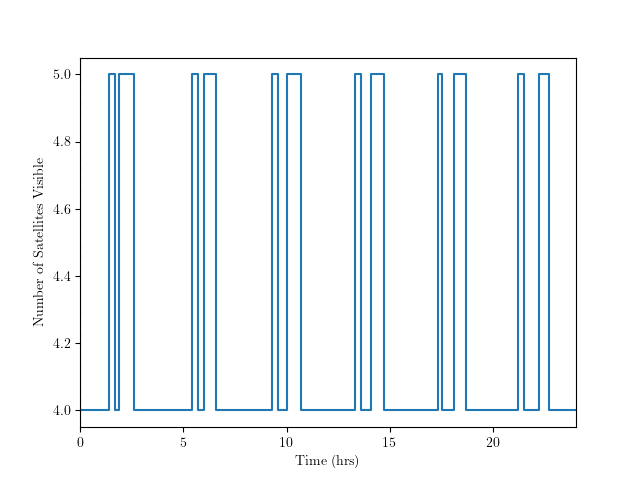

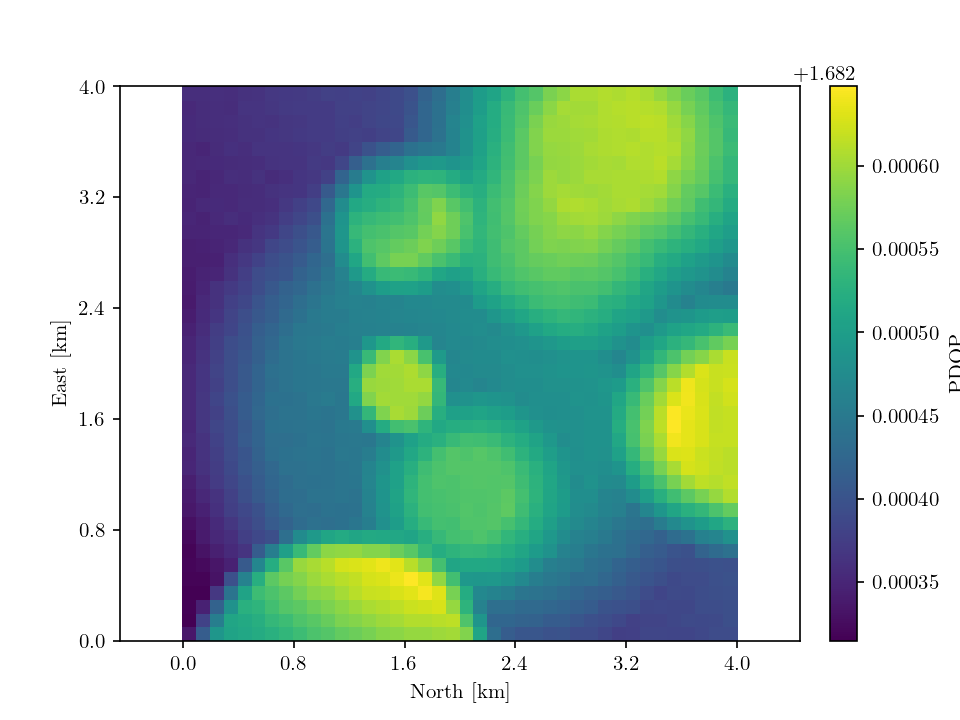

Text(0.5, 1.0, 'Time t = 0.00 hours')

In [7]:
# get the number of satellites that are visible at each time step
# if elevation is greater than 5, then the satellite is visible
tot_visible = np.sum(visible_sat_num, axis=0)

# plot as a step function
t = int(N_t*0/24)
plt.figure()
plt.step(tspan/3600, tot_visible)
plt.axvline(x=tspan[t]/3600, color='r', linestyle='--')
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)
plt.show()

# fig, ax = grid_env.plot_grid_elev(t=0, param_idx=2)
fig, ax = grid_env.plot_grid_elev(t=t, param_idx=2)
ax.set_title(f'Time t = {tspan[t]/3600:.2f} hours')

In [8]:
# np.rad2deg(grid_lat_long)

# A*

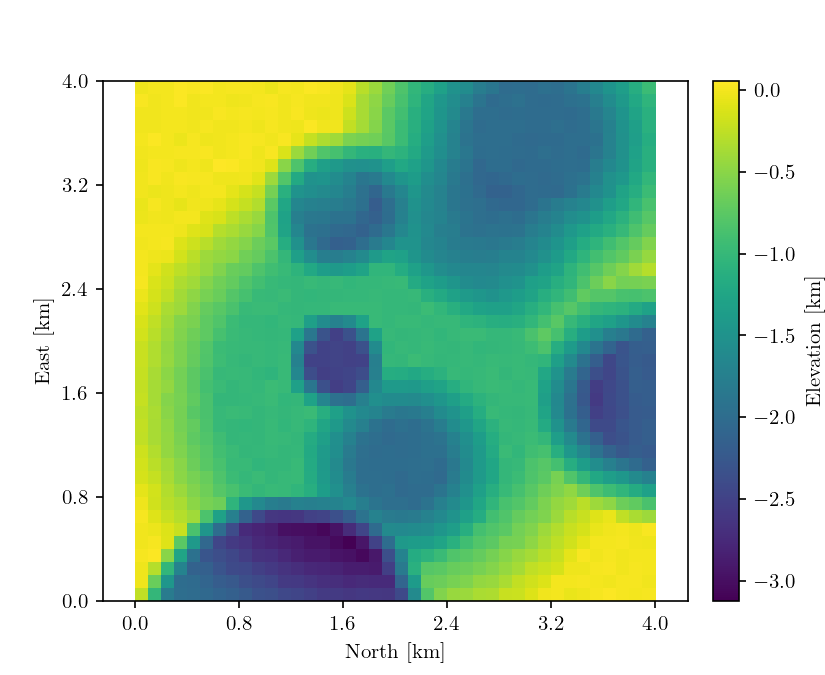

(58, 2)


In [9]:
# what we are passing in are the initial and goal inidices in the grid
x_init_idx = [7,5]
x_goal_idx = [35,30]
# get the initial and goal states in the grid
x_init = (resolution*x_init_idx[0], resolution*x_init_idx[1])
x_goal = (resolution*x_goal_idx[0], resolution*x_goal_idx[1])

# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
# obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
obstacles = None
weights = [1,1,1]
resolution = grid_env.res
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, tspan, resolution, True, obstacles, weights)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5.5, 4.5]
    # plt.rcParams['figure.figsize'] = [3, 3]
    fig, ax = astar.plot_path()
    # astar.plot_tree()

ax.set_title(f'Path Planning ($w_d$ = {weights[0]}, $w_e$ = {weights[1]}, $w_p$ = {weights[2]})')

waypoints = astar.get_waypoints(10)
# plot the downsampled path as scatter points
ax.plot(waypoints[:,1]/resolution, waypoints[:,0]/resolution, 'ko')

In [10]:
path_time = astar.reconstruct_time(path_plan)

In [11]:
path_time/3600

array([0.        , 0.11231588, 0.21780833, 0.36081238, 0.46270077,
       0.57517973, 0.67746026, 0.793472  , 0.90429327, 1.00938921,
       1.10960264, 1.22269635, 1.32309755, 1.47408863, 1.57408863,
       1.73897647, 1.95457961, 2.05512374, 2.15513891, 2.29667576,
       2.40838977, 2.50867715, 2.60867715, 2.70919922, 2.80931212,
       2.90949117, 3.01026909, 3.11160729, 3.21161677, 3.35306083,
       3.49456096, 3.59456096, 3.73653351, 3.87797947, 4.01982839,
       4.12255038, 4.22272644, 4.3236933 , 4.46813672, 4.60037209,
       4.74455398, 4.88618847, 5.02863542, 5.18065271, 5.33831294,
       5.48020221, 5.63909904, 5.78156108, 6.10969406, 6.37845999,
       6.5472619 , 6.72358918, 7.00126961, 7.19811288, 7.35555519,
       7.49898833, 7.64109886, 7.74157187])

In [12]:
len(path_time)

58

In [13]:
len(path_plan)

58

In [14]:
# rv_moon_sat_pa: Number of satellites x time vector x 6-state (x, y, z, vx, vy, vz)
ground_track = np.zeros((N_sat, N_t, 2))
ma = np.deg2rad([180, 0])
ma_4 = np.tile(ma, (1, 2))

for i_sat in range(N_sat):
    for t in range(N_t):
        # 
        pos_norm = np.linalg.norm(rv_moon_sat_pa[i_sat, t, :3])
        dec = np.arcsin(rv_moon_sat_pa[i_sat, t, 2] / pos_norm)
        if (rv_moon_sat_pa[i_sat, t, 1] / pos_norm) > 0:
            r_asc = np.arccos(rv_moon_sat_pa[i_sat, t, 0] / pos_norm / np.cos(dec))
        else:
            r_asc = 2 * np.pi - np.arccos(rv_moon_sat_pa[i_sat, t, 0] / pos_norm / np.cos(dec))
        dec = np.rad2deg(dec)
        r_asc = np.rad2deg(r_asc)
        ground_track[i_sat, t, :] = (dec, r_asc) # in radians

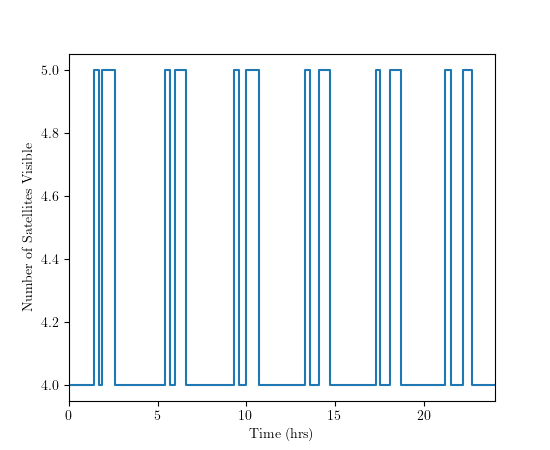

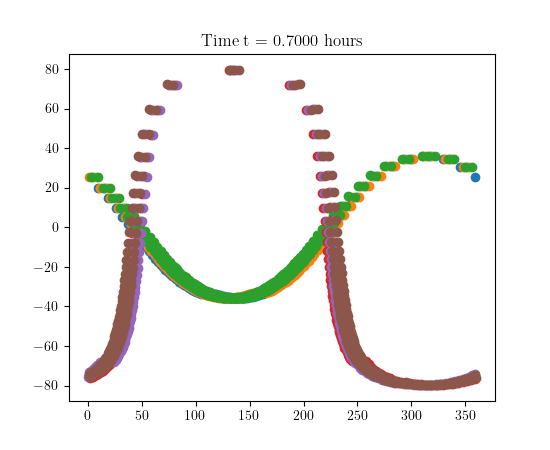

In [15]:
# get the number of satellites that are visible at each time step
# if elevation is greater than 5, then the satellite is visible

lent = len(tspan)
visible_sat = np.zeros((N_sat, lent))
for i_sat in range(N_sat):
    visible_sat[i_sat] = el_sat[i_sat] > 10
tot_visible = np.sum(visible_sat, axis=0)

# plot as a step function
plt.figure()
plt.step(tspan/3600, tot_visible)
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)

plt.show()

# fig, ax = grid_env.plot_grid_elev(t=0, param_idx=2)
t = int(N_t*1.5/48)
# fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0, lat_long = True)
fig, ax = plt.figure(), plt.gca()
ax.set_title(f'Time t = {tspan[t]/3600:.4f} hours')
for i_sat in range(N_sat):
    plt.scatter(ground_track[i_sat, :, 1], ground_track[i_sat, :, 0])
    # plt.scatter(ground_track[i_sat, t, 1], ground_track[i_sat, t, 0], s=30, color = 'k')
    # print((ground_track[i_sat, N_t-20, 1], ground_track[i_sat, N_t-20, 0]))




In [16]:
waypoints/resolution

array([[ 7.,  5.],
       [13.,  4.],
       [19.,  4.],
       [23., 11.],
       [23., 17.],
       [21., 23.],
       [19., 30.],
       [24., 35.],
       [30., 36.],
       [35., 30.]])

In [17]:
waypoints.shape
waypoints_grid = waypoints[:,:2]/resolution
print(waypoints_grid)

s0 = np.array([waypoints_grid[0, 0], waypoints_grid[0, 1], 0.0]) # initial state (should be previous waypoint)
s_goal = np.array([waypoints_grid[1, 0], waypoints_grid[1, 1], 0.0]) # desired final state (should be next waypoint)
print(s_goal)

[[ 7.  5.]
 [13.  4.]
 [19.  4.]
 [23. 11.]
 [23. 17.]
 [21. 23.]
 [19. 30.]
 [24. 35.]
 [30. 36.]
 [35. 30.]]
[13.  4.  0.]


In [18]:
# waypoints = astar.get_waypoints(10)
# waypoints_grid = waypoints/resolution
waypoints_grid = astar.get_waypoints(10)

# s0 = np.array([waypoints_grid[0, 0], waypoints_grid[0, 1], 0.0]) # initial state 
# s_goal = np.array([waypoints_grid[1, 0], waypoints_grid[1, 1], 0.0]) # desired final state

N = 5 # MPC horizon length
# P = 1e2 * np.eye(n)  # terminal state cost matrix
# Q = np.eye(n)
P = np.diag([10, 10, 1])*1e2
Q = np.diag([1, 1, 1])
R = 1e-2 * np.eye(2)  # control cost matrix

eps = 1e-3 # SCP convergence tolerance
N_scp = 10 # maximum number of SCP iterations
dt = 0.1 # time step (hrs)
T = 15 # total simulation time steps
v_bound = 1 # cells/time step
v_bound = (v_bound * resolution) / dt # km/hr
omega_bound = 3.0 # rad/hr
# omega_bound = 5.0 # deg/sec
# omega_bound *= np.pi/180 * 3600 # rad/hr

grid_coords, grid_lat_long = grid_env.grid_PA_coords(lat_user, lon_user)
grid_elev = grid_env.grid[:,:,0,2]

# s_mpc, u_mpc = run_mpc(s0, s_goal, N, P, Q, R, T, N_scp, dt, v_bound, omega_bound)
# plot_mpc(s0, s_goal, s_mpc, u_mpc, N, T, N_scp)

(58, 2)


In [19]:
n_waypt = len(waypoints_grid)
heading = np.zeros(n_waypt)
s_mpc_list = np.zeros((T * (n_waypt - 1), N + 1, 3)) # 300x6x3
# print(s_mpc_list.shape)
u_mpc_list = np.zeros((T * (n_waypt - 1), N, 2))
true_state_total = np.zeros((T * (n_waypt-1), 3))
est_state_total = np.zeros((T * (n_waypt-1), 3))

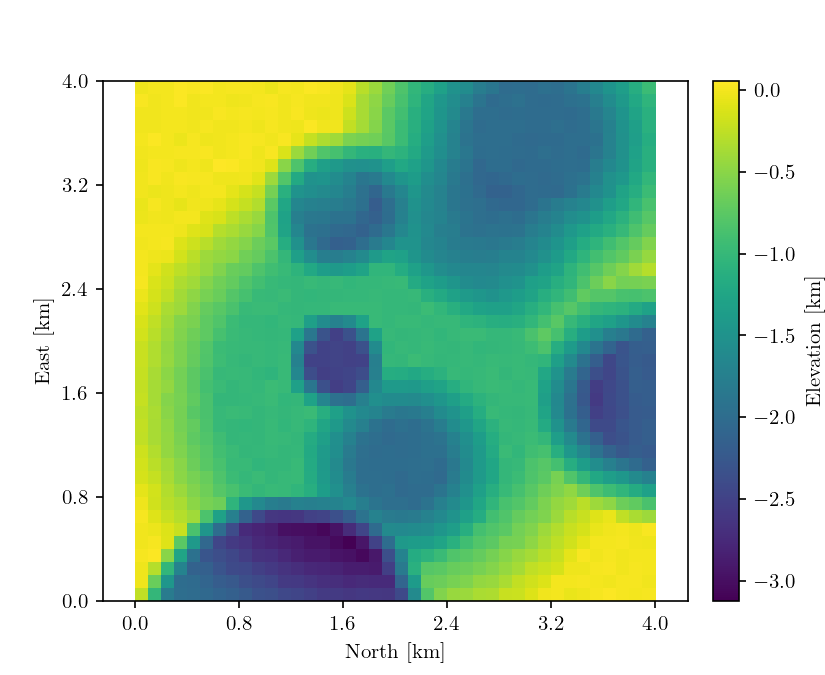

Initial state estimate: [ -844.74849686   289.74153822 -1492.28142916]
Initial rover estimate: [ 0.67254341  0.52848948 -0.16514868]
Intial covariance: [[0.0001 0.     0.    ]
 [0.     0.0001 0.    ]
 [0.     0.     0.0001]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.2155780792236328 seconds
Total control cost: 0.2462064388793046
Initial state estimate: [ -845.20853489   289.98333125 -1491.94951342]
Initial rover estimate: [ 1.31811411  0.37399285 -0.00219046]
Intial covariance: [[0.0001 0.     0.    ]
 [0.     0.0001 0.    ]
 [0.     0.     0.0001]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.1526618003845215 seconds
Total control cost: 0.421399281297038
Initial state estimate: [ -845.71109514   290.14371845 -1491.65337813]
Initial rover estimate: [1.89373834 0.39611642 1.05158013]
Intial covariance: [[0.0001 0.     0.    ]
 [0.     0.0001 0.    ]
 [0.     0.     0.0001]]


...

Total elapsed time: 1.4183030128479004 seconds
Total control cost: 0.30399924912404064
Initial state estimate: [ -846.61803537   288.79007375 -1491.37781459]
Initial rover estimate: [2.42922242 3.45461925 0.16523031]
Intial covariance: [[0.0001 0.     0.    ]
 [0.     0.0001 0.    ]
 [0.     0.     0.0001]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.1638789176940918 seconds
Total control cost: 0.4349005538790363
Initial state estimate: [ -847.1214032    288.90248103 -1491.07638263]
Initial rover estimate: [ 3.01460322  3.5635601  -0.87600818]
Intial covariance: [[0.0001 0.     0.    ]
 [0.     0.0001 0.    ]
 [0.     0.     0.0001]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.605247974395752 seconds
Total control cost: 0.27911331086868013


In [20]:
# fig, ax = plt.subplots()
fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0)


for i in range(len(waypoints_grid) - 1):
    waypt = waypoints_grid[i]
    next_waypt = waypoints_grid[i+1]
    xdist = next_waypt[0] - waypt[0]
    ydist = next_waypt[1] - waypt[1]
    heading[i] = np.arctan2(ydist, xdist)
heading[-1] = heading[-2]

# print(heading)
ekf_on = True

if not ekf_on:
    s0 = np.array([waypoints_grid[0,0], waypoints_grid[0,1], heading[0]])  # overall initial state
    for i in range(len(waypoints_grid) - 1):
        waypt = waypoints_grid[i]
        print(s0)
        print(np.array([waypt[0], waypt[1], heading[i]]))
        next_waypt = waypoints_grid[i+1]
        # s0 = np.array([waypt[0], waypt[1], heading[i]])
        s_goal = np.array([next_waypt[0], next_waypt[1], heading[i+1]])
        s_mpc, u_mpc, s_true = mpc.run_mpc(s0, s_goal, N, P, Q, R, T, N_scp, dt, v_bound, omega_bound)
        
        s_mpc_list[(T * i):(T * (i+1)), :, :] = s_mpc
        u_mpc_list[(T * i):(T * (i+1)), :, :] = u_mpc
        # retrieve the very last state of the rover to set as the new initial state for the next MPC
        s_final = s_true[-1, :]

        ax.plot(s_mpc[:, 0, 1]/resolution, s_mpc[:, 0, 0]/resolution, "-o", color = 'tab:blue',label = 'MPC Path' if i == 0 else None)
        ax.scatter(s0[1]/resolution, s0[0]/resolution,color='k',zorder=3, label = 'Initial State' if i == 0 else None) 
        ax.scatter(s_goal[1]/resolution, s_goal[0]/resolution,color='r',zorder=3, label = 'Final State' if i == 0 else None) 

        # the final state of the previous iteration is the initial state of the next iteration
        s0 = np.copy(s_final)

else:
    t_true = 0
    s0 = np.array([waypoints_grid[0,0], waypoints_grid[0,1], heading[0]])  # overall initial state
    cov_final = None
    s_final_est = None
    
    for i in range(len(waypoints_grid) - 1):
        next_waypt = waypoints_grid[i+1]
        s_goal = np.array([next_waypt[0], next_waypt[1], heading[i+1]])
        s_mpc, u_mpc, t_true, true_state_array, est_state_array, cov_final = mpc_EKF.run_ekf_mpc(s0, s_goal, N, P, Q, R, T, N_scp, dt, v_bound, omega_bound, rv_moon_sat_pa, tspan, t_true, [lat_user, lon_user], grid_elev, s_final_est, cov_final)
        
        # let's collect the true states
        # don't include the last state since it's the goal state and where the rover begins at the next iteration
        true_state_total[(T * i):(T * (i+1)), :] = true_state_array[:-1,:]
        est_state_total[(T * i):(T * (i+1)), :] = est_state_array[:-1,:]
        u_mpc_list[(T * i):(T * (i+1)), :, :] = u_mpc
        s_mpc_list[(T * i):(T * (i+1)), :, :] = s_mpc
        # get where the rover actually ended up
        s_final = true_state_array[-1, :]
        s_final_est = est_state_array[-1, :]

        
        ax.plot(s_mpc[:, 0, 1]/resolution, s_mpc[:, 0, 0]/resolution, "-o", color = 'tab:blue', label = 'MPC Path' if i == 0 else None)
        ax.plot(true_state_array[:, 1]/resolution, true_state_array[:, 0]/resolution, "--o", color = 'tab:orange', label = 'True Path' if i == 0 else None)
        ax.scatter(s0[1]/resolution, s0[0]/resolution,color='k',zorder=3, label = 'Initial State' if i == 0 else None) 
        ax.scatter(s_goal[1]/resolution, s_goal[0]/resolution,color='r',zorder=3, label = 'Final State' if i == 0 else None) 

        # the final state of the previous iteration is the initial state of the next iteration
        s0 = np.copy(s_final)

ax.axis("equal")
plt.legend()
# plt.gca().invert_yaxis()

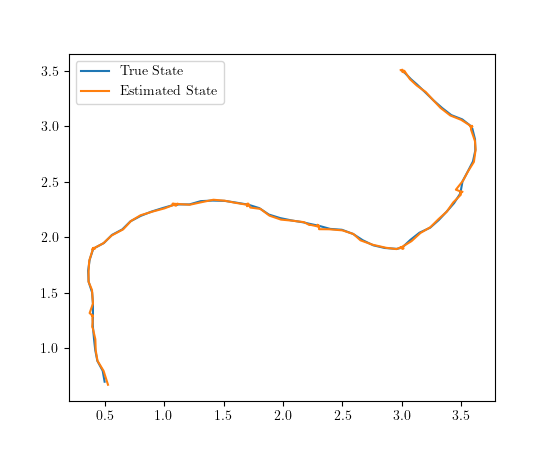

In [21]:
fig = plt.figure()
plt.plot(true_state_total[:, 1], true_state_total[:, 0], label='True State') 
plt.plot(est_state_total[:, 1], est_state_total[:, 0], label='Estimated State') 
plt.legend()

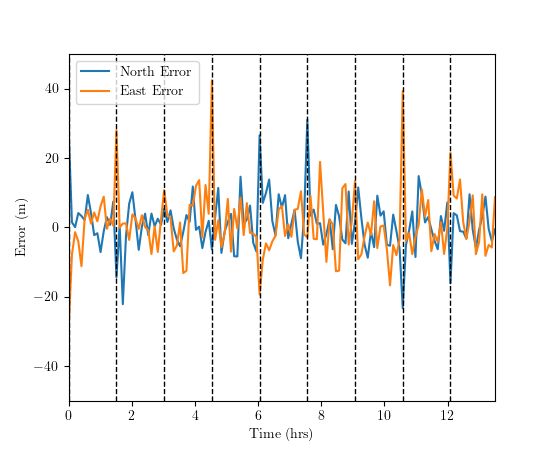

In [40]:
t_vec = np.linspace(0, t_true/3600, len(true_state_total[:, 0]))

fig = plt.figure()
plt.plot(t_vec, (true_state_total[:, 0] - est_state_total[:, 0])*1000, label='North Error')
plt.plot(t_vec, (true_state_total[:, 1] - est_state_total[:, 1])*1000, label='East Error')
plt.vlines(t_vec[::T], -50, 50, color='k', linestyle='--', linewidth=1)   
plt.xlabel('Time (hrs)')
plt.ylabel('Error (m)')
plt.ylim(-50, 50)
plt.xlim(0, t_vec[-1])
# plt.grid()
plt.legend()

In [23]:
true_state_total[-1]

array([ 3.50531299,  2.99945302, -0.87736009])

In [24]:
est_state_total[-1]

array([ 3.50594634,  2.99080383, -0.87736009])

In [43]:
t_vec[::T]

array([ 0.        ,  1.51119403,  3.02238806,  4.53358209,  6.04477612,
        7.55597015,  9.06716418, 10.57835821, 12.08955224])

[0.7 1.3 1.9 2.3 2.3 2.1 1.9 2.4 3.  3.5]
Waypoint 1 at t = 0.0
Waypoint 2 at t = 1.5111940298507462
Waypoint 3 at t = 3.0223880597014925
Waypoint 4 at t = 4.5335820895522385
Waypoint 5 at t = 6.044776119402985
Waypoint 6 at t = 7.5559701492537314
Waypoint 7 at t = 9.067164179104477
Waypoint 8 at t = 10.578358208955224
Waypoint 9 at t = 12.08955223880597


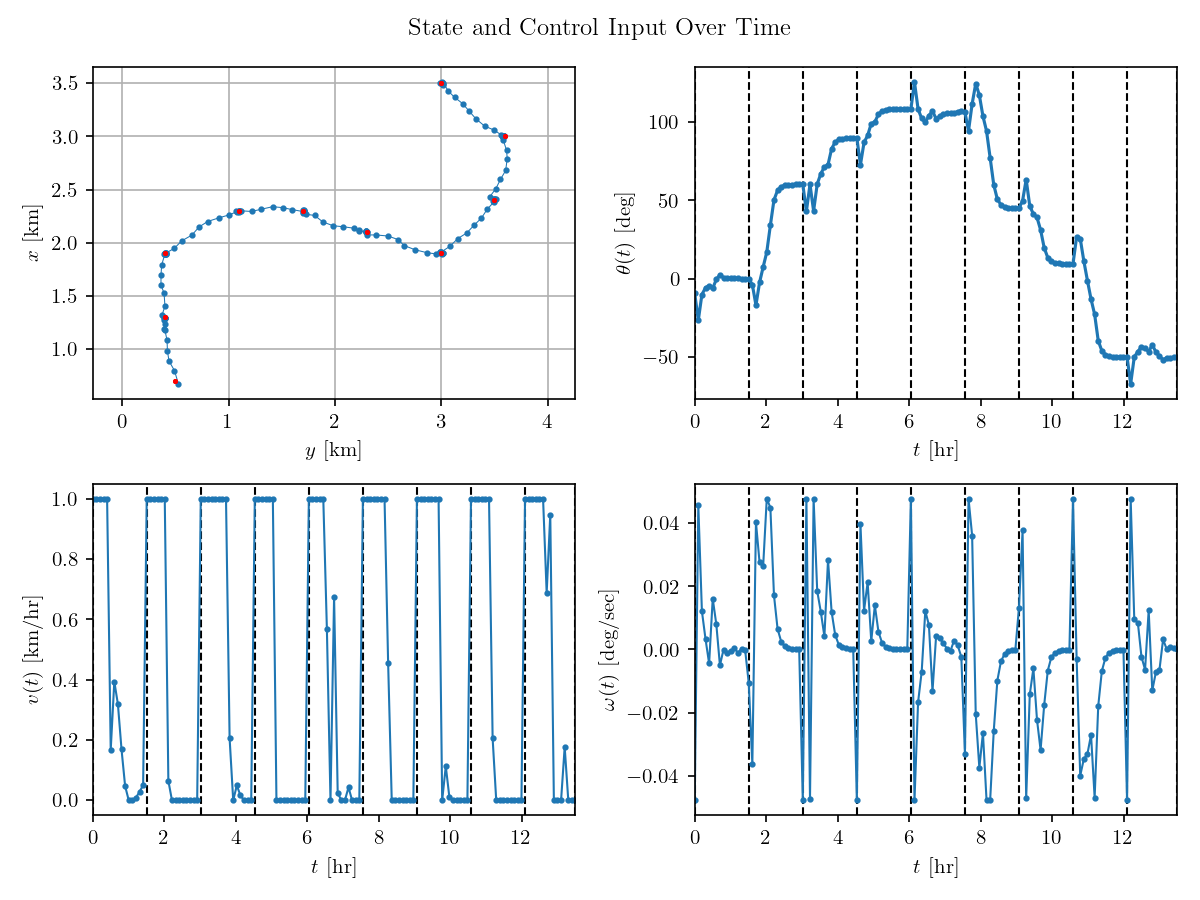

In [42]:
first_waypt, last_waypt = waypoints_grid[0], waypoints_grid[-1]
print(waypoints_grid[:, 0])
# s0 = np.array([first_waypt[0], first_waypt[1], heading[0]])
# s_goal = np.array([last_waypt[0], last_waypt[1], heading[-1]])
s0 = np.array([waypoints_grid[:, 0], waypoints_grid[:, 1], heading])
s_goal = s0
# s_goal = np.array([last_waypt[0], last_waypt[1], heading[-1]])
mpc.plot_mpc(s0, s_goal, s_mpc_list, u_mpc_list, N, T, N_scp, n_waypt, dt)
plt.show()

In [27]:
waypoints_grid

array([[0.7, 0.5],
       [1.3, 0.4],
       [1.9, 0.4],
       [2.3, 1.1],
       [2.3, 1.7],
       [2.1, 2.3],
       [1.9, 3. ],
       [2.4, 3.5],
       [3. , 3.6],
       [3.5, 3. ]])

In [28]:
np.sqrt((1.3-0.7)**2 + (0.4-0.5)**2)

0.608276253029822

# EKF TIME

In [29]:
rv_moon_sat_pa.shape

(6, 241, 6)

In [30]:
tspan

array([    0.,   360.,   720.,  1080.,  1440.,  1800.,  2160.,  2520.,
        2880.,  3240.,  3600.,  3960.,  4320.,  4680.,  5040.,  5400.,
        5760.,  6120.,  6480.,  6840.,  7200.,  7560.,  7920.,  8280.,
        8640.,  9000.,  9360.,  9720., 10080., 10440., 10800., 11160.,
       11520., 11880., 12240., 12600., 12960., 13320., 13680., 14040.,
       14400., 14760., 15120., 15480., 15840., 16200., 16560., 16920.,
       17280., 17640., 18000., 18360., 18720., 19080., 19440., 19800.,
       20160., 20520., 20880., 21240., 21600., 21960., 22320., 22680.,
       23040., 23400., 23760., 24120., 24480., 24840., 25200., 25560.,
       25920., 26280., 26640., 27000., 27360., 27720., 28080., 28440.,
       28800., 29160., 29520., 29880., 30240., 30600., 30960., 31320.,
       31680., 32040., 32400., 32760., 33120., 33480., 33840., 34200.,
       34560., 34920., 35280., 35640., 36000., 36360., 36720., 37080.,
       37440., 37800., 38160., 38520., 38880., 39240., 39600., 39960.,
      

In [31]:
grid_elev.shape

(40, 40)